# Stock Price Time Series Analysis

Downloading historical stock data for **Apple (AAPL)** and
**Microsoft (MSFT)**, then applying Pandas time series
techniques — date indexing, resampling, and rolling moving
averages — to compare performance over 2022–2024.

**Project:** https://roadmap.sh/projects/stock-price-time-series

In [1]:
# Author:      Wajid Ali Saleem Chaudhry
# Description: Stock price time series analysis with
#              yfinance and Pandas.

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import yfinance as yf

# --- Setup ---

Path("outputs").mkdir(exist_ok=True)

TICKERS = ["AAPL", "MSFT"]
START   = "2022-01-01"
END     = "2024-12-31"

print(f"Tickers : {TICKERS}")
print(f"Period  : {START}  →  {END}")

Tickers : ['AAPL', 'MSFT']
Period  : 2022-01-01  →  2024-12-31


## Data Acquisition

Three years of daily OHLCV data downloaded via `yfinance`.
`auto_adjust=True` adjusts prices for stock splits and
dividends so the series is comparable across the full period.

In [2]:
# --- Data Acquisition ---

# Download 3 years of daily OHLCV; auto_adjust corrects
# for splits and dividends
raw = yf.download(
    TICKERS,
    start=START,
    end=END,
    auto_adjust=True,
    progress=False,
)
print(f"Shape   : {raw.shape}")
print(f"Columns : {list(raw.columns[:4])} ...")
raw.tail(3)

Shape   : (752, 10)
Columns : [('Close', 'AAPL'), ('Close', 'MSFT'), ('High', 'AAPL'), ('High', 'MSFT')] ...


Price            Close                    High                     Low  \
Ticker            AAPL        MSFT        AAPL        MSFT        AAPL   
Date                                                                     
2024-12-26  257.375610  432.973633  258.448771  435.770471  255.994450   
2024-12-27  253.967392  425.482544  257.057664  430.117562  251.453455   
2024-12-30  250.598907  419.849335  251.890657  422.537447  249.158116   

Price                         Open                Volume            
Ticker            MSFT        AAPL        MSFT      AAPL      MSFT  
Date                                                                
2024-12-26  431.511003  256.550893  433.932262  27237100   8194200  
2024-12-27  421.351557  256.193162  429.504835  42355300  18117700  
2024-12-30  416.953693  250.628716  421.064925  35557500  13158700

## Data Preparation

`yfinance` already returns a `DatetimeIndex` — no manual
conversion needed. We slice `Close` and `Volume` into
tidy DataFrames, each indexed by date with one column per
ticker.

In [3]:
# --- Data Preparation ---

# Slice into close/volume DataFrames
close  = raw["Close"]
volume = raw["Volume"]

print(f"Index type   : {type(close.index).__name__}")
print(
    f"Date range   : {close.index[0].date()}",
    f"→ {close.index[-1].date()}",
)
print(f"Trading days : {len(close)}")
close.tail(5)

Index type   : DatetimeIndex
Date range   : 2022-01-03 → 2024-12-30
Trading days : 752


Ticker,AAPL,MSFT
Date,,
2024-12-23,253.649414,430.147217
2024-12-24,256.560791,434.179321
2024-12-26,257.375610,432.973633
2024-12-27,253.967392,425.482544
2024-12-30,250.598907,419.849335


## Closing Prices

Daily adjusted close for both tickers on the same axes to
highlight relative performance and directional correlation.

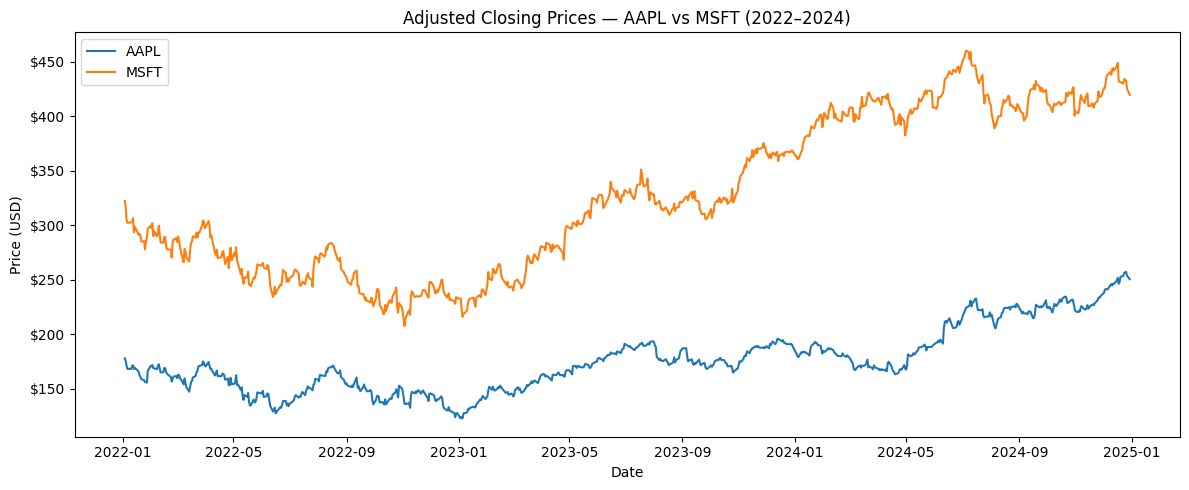

In [4]:
# --- Closing Prices Chart ---

fig, ax = plt.subplots(figsize=(12, 5))

for ticker in TICKERS:
    ax.plot(close.index, close[ticker], label=ticker)

ax.set_title(
    "Adjusted Closing Prices — AAPL vs MSFT (2022–2024)"
)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
ax.legend()
plt.tight_layout()
plt.savefig("outputs/closing_prices.png", dpi=150)
plt.show()

## Resampling — Weekly and Monthly

`.resample()` aggregates the daily series to coarser
frequencies. The mean close per period smooths day-to-day
noise and reveals multi-month trends more clearly.

Daily rows → weekly : 752 → 157 → monthly : 36


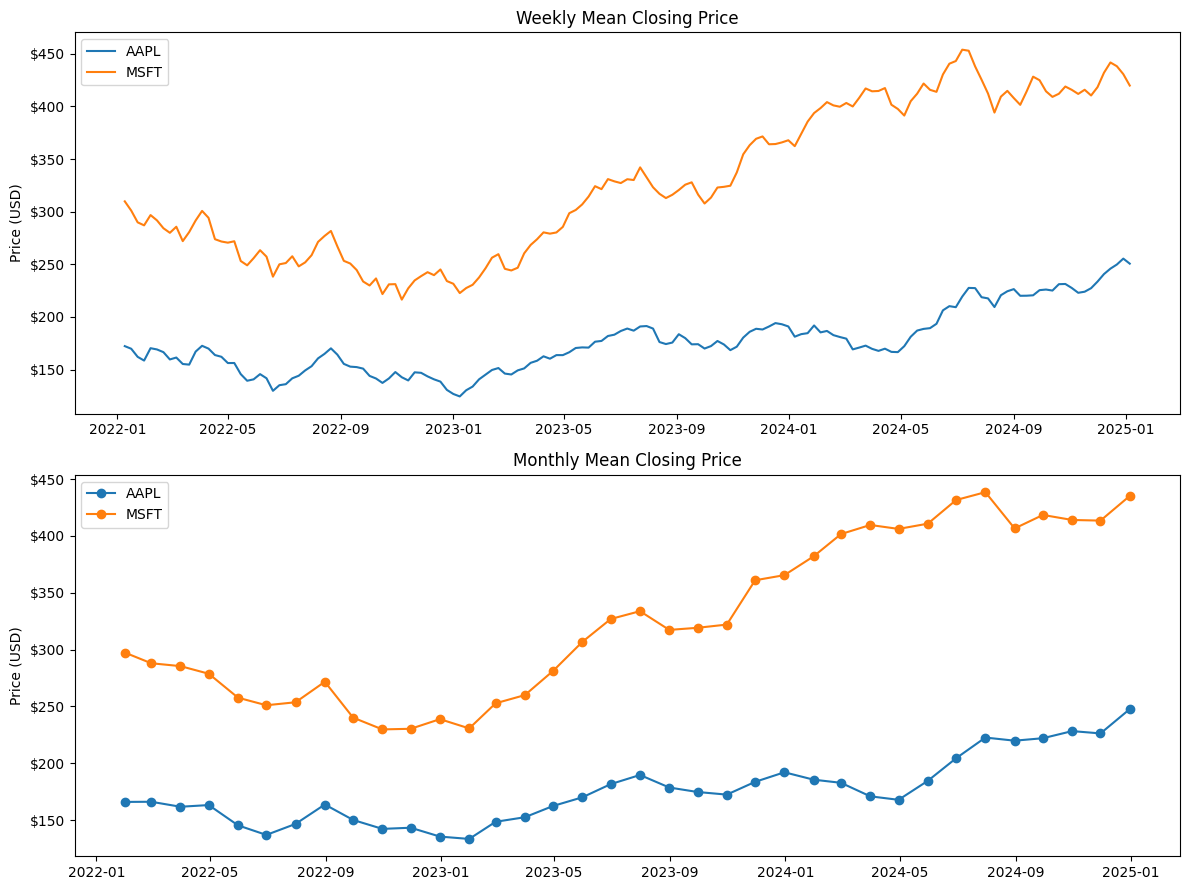

In [5]:
# --- Resampling ---

# "W" = week-ending Sunday; "ME" = month-end
close_weekly  = close.resample("W").mean()
close_monthly = close.resample("ME").mean()

print(
    f"Daily rows → weekly : {len(close)}",
    f"→ {len(close_weekly)}",
    f"→ monthly : {len(close_monthly)}",
)

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=False)

for ticker in TICKERS:
    axes[0].plot(
        close_weekly.index,
        close_weekly[ticker],
        label=ticker,
    )
    axes[1].plot(
        close_monthly.index,
        close_monthly[ticker],
        marker="o",
        label=ticker,
    )

axes[0].set_title("Weekly Mean Closing Price")
axes[1].set_title("Monthly Mean Closing Price")

for ax in axes:
    ax.set_ylabel("Price (USD)")
    ax.legend()
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
    )

plt.tight_layout()
plt.savefig("outputs/resampled_prices.png", dpi=150)
plt.show()

## Moving Averages

The **20-day MA** (short-term trend) and **200-day MA**
(long-term trend) are computed with `.rolling().mean()`.
When the 20-day crosses above the 200-day it forms a
"golden cross" — a classic bullish signal.

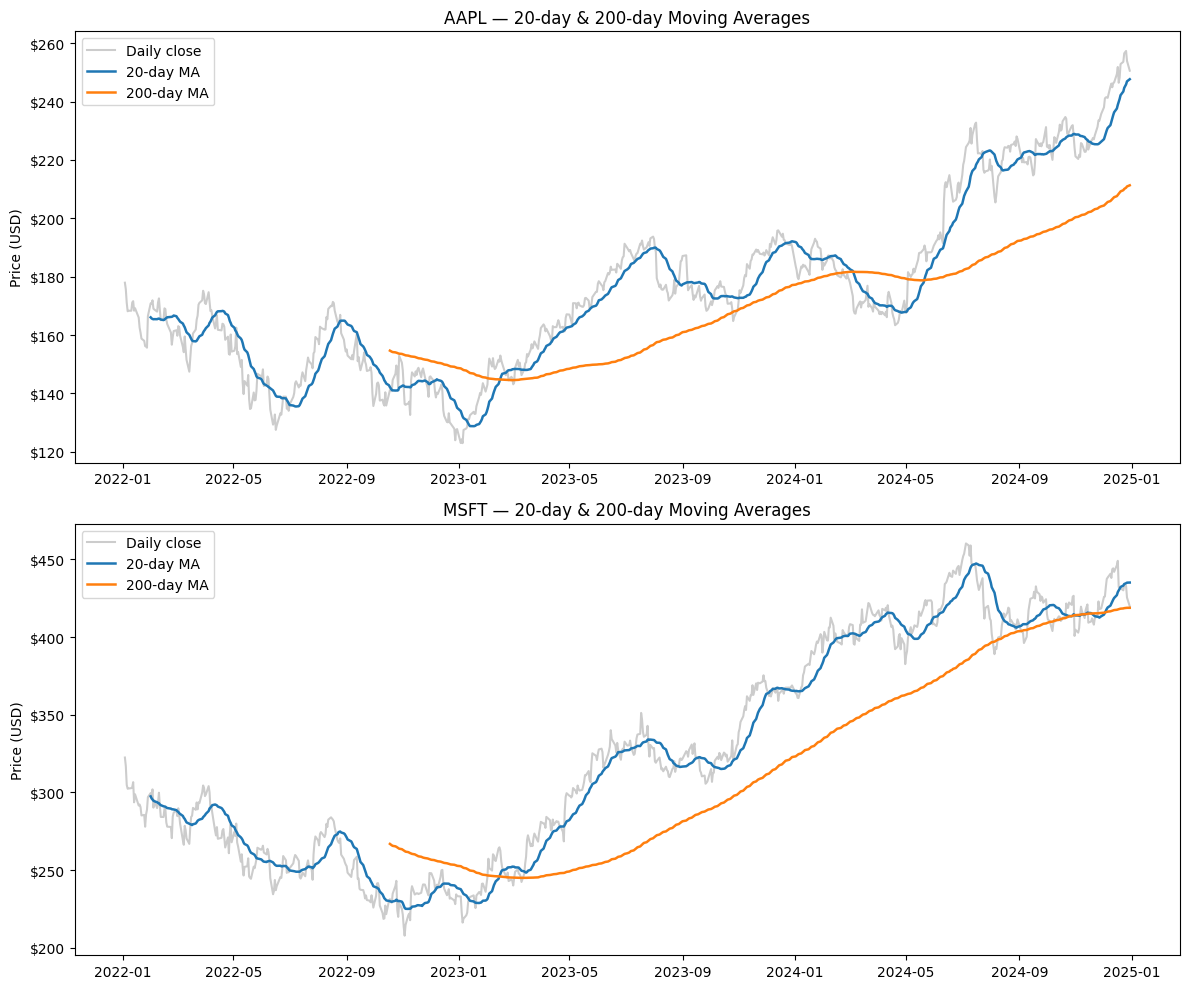

In [6]:
# --- Moving Averages ---

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

for i, ticker in enumerate(TICKERS):
    ma20  = close[ticker].rolling(20).mean()
    ma200 = close[ticker].rolling(200).mean()

    axes[i].plot(
        close.index, close[ticker],
        alpha=0.4, color="gray", label="Daily close",
    )
    axes[i].plot(
        close.index, ma20, lw=1.8, label="20-day MA",
    )
    axes[i].plot(
        close.index, ma200, lw=1.8, label="200-day MA",
    )
    axes[i].set_title(
        f"{ticker} — 20-day & 200-day Moving Averages"
    )
    axes[i].set_ylabel("Price (USD)")
    axes[i].legend()
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
    )

plt.tight_layout()
plt.savefig("outputs/moving_averages.png", dpi=150)
plt.show()

## Volume Comparison

Trading volume reflects market activity and liquidity.
AAPL typically trades far more shares per day than MSFT,
consistent with its larger retail investor base.

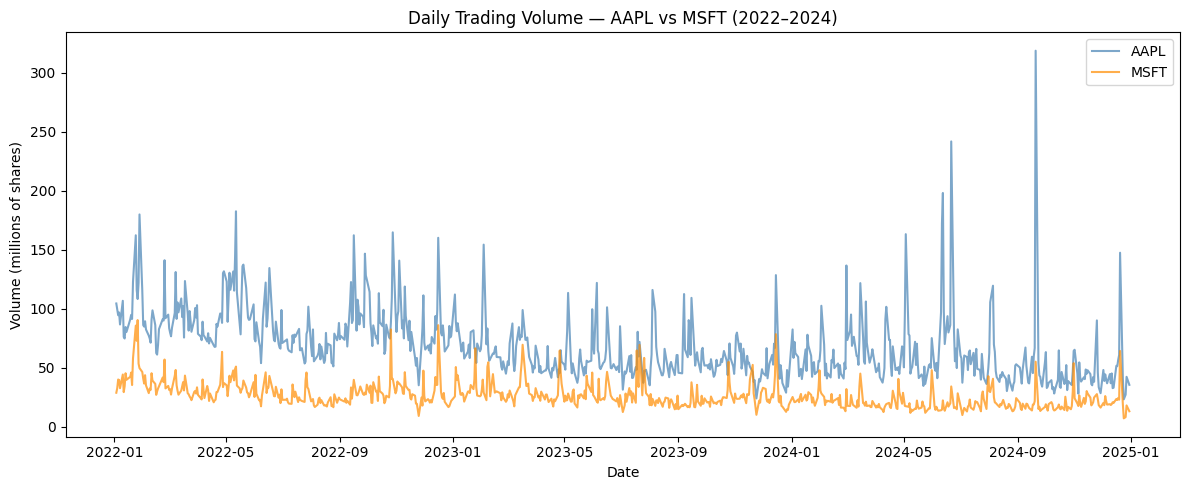

In [7]:
# --- Volume Comparison ---

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    volume.index, volume["AAPL"] / 1e6,
    alpha=0.7, label="AAPL", color="steelblue",
)
ax.plot(
    volume.index, volume["MSFT"] / 1e6,
    alpha=0.7, label="MSFT", color="darkorange",
)

ax.set_title(
    "Daily Trading Volume — AAPL vs MSFT (2022–2024)"
)
ax.set_xlabel("Date")
ax.set_ylabel("Volume (millions of shares)")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/volume_comparison.png", dpi=150)
plt.show()

## Findings

In [8]:
# --- Findings Summary ---

# Print key stats per ticker
for ticker in TICKERS:
    s   = close[ticker]
    vol = volume[ticker]
    ret = (s.iloc[-1] / s.iloc[0] - 1) * 100
    print(f"{ticker}")
    print(f"  Period return     : {ret:+.1f}%")
    print(f"  Max closing price : ${s.max():,.2f}")
    print(
        f"  Avg daily volume  :",
        f"{vol.mean() / 1e6:.1f}M shares",
    )
    print()

AAPL
  Period return     : +40.8%
  Max closing price : $257.38
  Avg daily volume  : 68.1M shares

MSFT
  Period return     : +30.2%
  Max closing price : $460.33
  Avg daily volume  : 26.5M shares

